In [2]:
# Some derivations for the braid matrix

# ((tt -> a) at -> c) ((tt -> b) bt -> d) cd -> 1
()

()

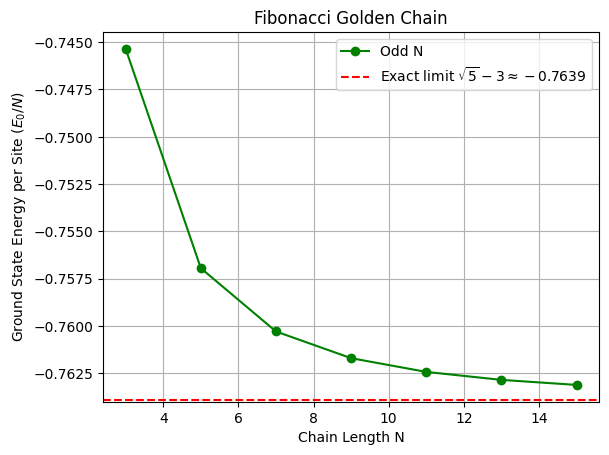

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

phi = (1 + np.sqrt(5)) / 2
exact_E_per_site = np.sqrt(5) - 3

def get_basis(N):
    basis = []
    for i in range(2**N):
        s = bin(i)[2:].zfill(N)
        if '00' not in s:
            if s[0] == '0' and s[-1] == '0':
                continue
            basis.append(s)
    return basis

def build_hamiltonian(N, basis):
    dim = len(basis)
    H = lil_matrix((dim, dim), dtype=float)
    basis_dict = {s: i for i, s in enumerate(basis)}
    
    for i in range(N):
        prev_i = (i - 1) % N
        next_i = (i + 1) % N
        
        for j, s in enumerate(basis):
            if s[prev_i] == '1' and s[next_i] == '1':
                if s[i] == '0':
                    H[j, j] -= 1.0 / (phi**2)
                    s_new = s[:i] + '1' + s[i+1:]
                    k = basis_dict[s_new]
                    H[k, j] -= 1.0 / (phi**1.5)
                elif s[i] == '1':
                    H[j, j] -= 1.0 / phi
                    s_new = s[:i] + '0' + s[i+1:]
                    k = basis_dict[s_new]
                    H[k, j] -= 1.0 / (phi**1.5)
            elif s[prev_i] == '0' and s[next_i] == '0':
                H[j, j] -= 1.0
                
    return H.tocsr()

Ns = range(3,17,2)
Es = []

for N in Ns:
    basis = get_basis(N)
    H = build_hamiltonian(N, basis)
    
    if H.shape[0] <= 2:
        w, v = np.linalg.eigh(H.toarray())
        e0 = w[0]
    else:
        w, v = eigsh(H, k=1, which='SA')
        e0 = w[0]
    
    Es.append(e0 / N)


#plt.plot(even_df.N, even_df.E, 'bo-', label='Even N')
plt.plot(Ns, Es, 'go-', label='Odd N')
plt.axhline(exact_E_per_site, color='r', linestyle='--', label=f'Exact limit $\\sqrt{{5}}-3 \\approx {exact_E_per_site:.4f}$')
plt.xlabel('Chain Length N')
plt.ylabel('Ground State Energy per Site ($E_0/N$)')
plt.title('Fibonacci Golden Chain')
plt.legend()
plt.grid(True)
plt.savefig('convergence_plot.png')

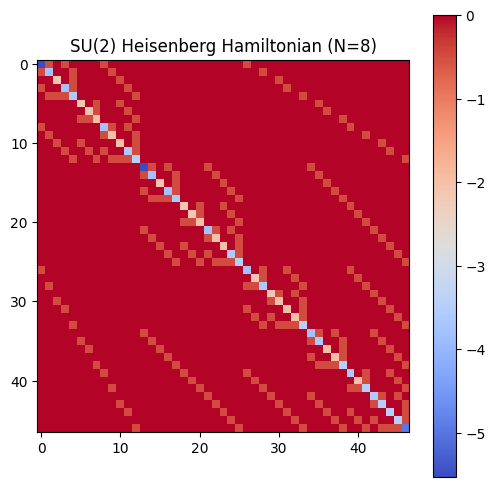

In [4]:
import matplotlib.pyplot as plt

N = 8
basis = get_basis(N)
H = build_hamiltonian(N, basis).toarray()

plt.figure(figsize=(6,6))
plt.imshow(H, cmap='coolwarm')
plt.colorbar()
plt.title(f"SU(2) Heisenberg Hamiltonian (N={N})")
plt.show()

In [5]:
import numpy as np
from scipy.sparse import lil_matrix

def bit(i, N):
    return format(i, f"0{N}b")

def spin(i, pos):
    return (i >> pos) & 1


def swap_bits(i, a, b):
    sa = (i >> a) & 1
    sb = (i >> b) & 1
    if sa == sb:
        return i
    # flip bits
    i ^= (1 << a)
    i ^= (1 << b)
    return i


def build_su2_hamiltonian(N):
    dim = 2**N
    H = lil_matrix((dim, dim), dtype=float)

    for state in range(dim):
        for i in range(N):
            j = (i + 1) % N

            swapped = swap_bits(state, i, j)

            H[state, state] += -0.25
            H[swapped, state] += 0.5

    return H.tocsr()

In [6]:
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
Ns = range(4, 16)
Es = []

for N in Ns:
    H = build_su2_hamiltonian(N)

    e0 = eigsh(H, k=1, which='SA', return_eigenvectors=False)[0]
    e0, v0 = eigsh(H, k=1, which='SA', return_eigenvectors=True)
    psi = v0[:, 0]
    Es.append(e0 / N)



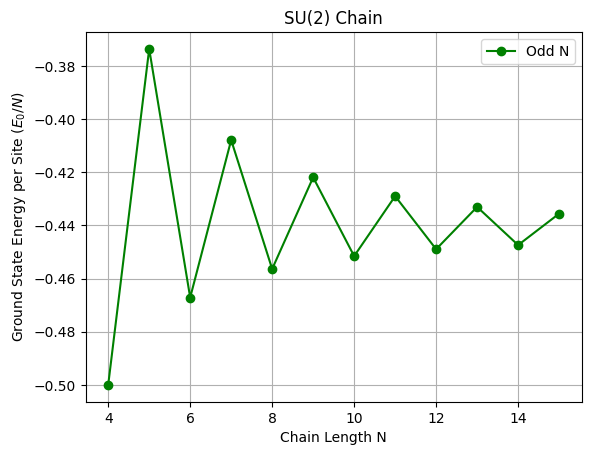

In [8]:
plt.plot(Ns, Es, 'go-', label='Odd N')
plt.xlabel('Chain Length N')
plt.ylabel('Ground State Energy per Site ($E_0/N$)')
plt.title('SU(2) Chain')
plt.legend()
plt.grid(True)
plt.savefig('convergence_plot.png')

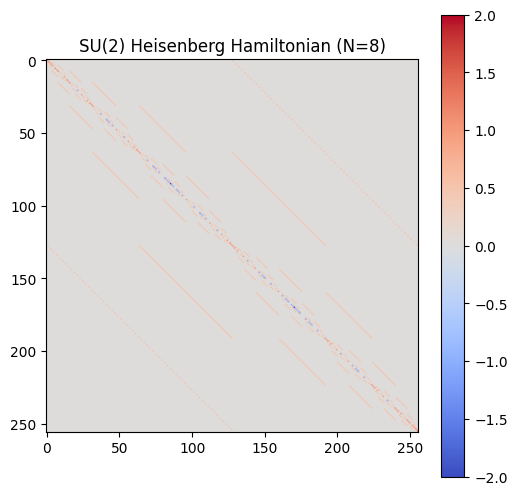

In [9]:
import matplotlib.pyplot as plt

N = 8
H = build_su2_hamiltonian(N).toarray()

plt.figure(figsize=(6,6))
plt.imshow(H, cmap='coolwarm')
plt.colorbar()
plt.title(f"SU(2) Heisenberg Hamiltonian (N={N})")
plt.show()

-0.7
0.30000000000000004
6.3
21.3
41.3
56.3
62.3


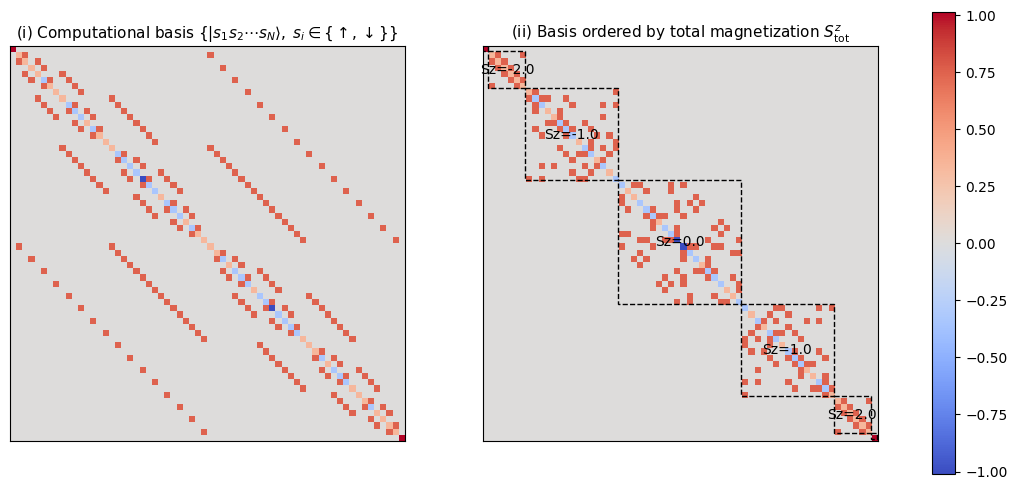

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch

N = 6
J = -1.5
Delta = 0.45


def _bit(x, N):
  return [int(b) for b in format(x, f"0{N}b")]


def num(b):
  return int("".join(map(str, b)), 2)


def flip(b, i, j):
  b = b.copy()
  b[i] ^= 1
  b[j] ^= 1
  return b


def build_xxz_hamiltonian(N, J, Delta):
  dim = 2**N
  H = np.zeros((dim, dim), dtype=float)

  for x in range(dim):
    b = _bit(x, N)
    for i in range(N):
      j = (i + 1) % N
      if b[i] == b[j]:
        H[x, x] -= J * Delta / 4
      else:
        H[x, x] += J * Delta / 4
        y = num(flip(b, i, j))
        H[x, y] -= J / 2
  return H


H = build_xxz_hamiltonian(N, J, Delta)
dim = 2**N


def magnetization(x):
  return bin(x).count("1")


sorted_idx = np.argsort([magnetization(x) for x in range(dim)])

H_sorted = H[np.ix_(sorted_idx, sorted_idx)]

counts = {}
for x in range(dim):
  m = magnetization(x)
  counts[m] = counts.get(m, 0) + 1

m_vals = sorted(counts.keys())
block_sizes = [counts[m] for m in m_vals]
boundaries = np.cumsum([0] + block_sizes)

Sz_labels = [0.5 * (2 * m - N) for m in m_vals]

basis_labels_sorted = [f"{'↑' * m + '↓' * (N - m)}" for m in m_vals]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

cmap = "coolwarm"

im0 = axs[0].imshow(H, cmap=cmap)

im1 = axs[1].imshow(H_sorted, cmap=cmap)

for i, (sz, size) in enumerate(zip(Sz_labels, block_sizes)):
  start = boundaries[i] - 0.7
  end = boundaries[i + 1] - 0.7
  print(start)

  rect = patches.Rectangle(
    (start, start),
    end - start,
    end - start,
    edgecolor="black",
    facecolor="none",
    linewidth=1,
    linestyle="--",
  )
  axs[1].add_patch(rect)

  if sz not in [4.0, 3.0, -3.0, -4.0]:
    axs[1].text(
      (start + end) / 2,
      (start + end) / 2,
      f"Sz={sz:.1f}",
      color="black",
      ha="center",
      va="center",
      fontsize=10,
    )

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])

axs[0].set_title(
    r"(i) Computational basis "
    r"$\{|s_1 s_2 \cdots s_N\rangle,\; s_i\in\{\uparrow,\downarrow\}\}$",
    fontsize=11,
)

axs[1].set_title(
    r"(ii) Basis ordered by total magnetization $S^z_{\mathrm{tot}}$",
    fontsize=11,
)

#axs[0].text(
#    0.5, 1.08,
#    r"$\{|s_1 s_2 \cdots s_N\rangle\}$",
##    transform=axs[0].transAxes,
#    ha="center",
#)

#axs[1].text(
#    0.5, 1.08,
#    r"$\bigoplus_M  H_M$ "
#    r"(grouped by magnetization sector)",
#    transform=axs[1].transAxes,
#    ha="center",
#)

cbar = fig.colorbar(im1, ax=axs, location="right")

# plt.tight_layout()
plt.show()
fig.savefig("plots/xxz_hamiltonian.pdf", dpi=300, bbox_inches="tight")
fig.savefig("plots/xxz_hamiltonian.png", dpi=300, bbox_inches="tight")